In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten,BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.layers import Convolution2D,Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.compat.v1 import ConfigProto
from tensorflow.compat.v1 import InteractiveSession
from keras import optimizers
from tensorflow.keras.preprocessing import image
import os

In [2]:
# Root folder of the dataset
# Dataset URL-> https://www.kaggle.com/paultimothymooney/chest-xray-pneumonia
# datasetFolderName='/Users/AJEET SINGH/DownloadsD:\Python\pythonProject\code\medicalimage_classfication\DS2\DS2'
datasetFolderName='DS2/DS2'
# Model file name for saving    
MODEL_FILENAME="imageClassificationModel.keras"
# Input image dimensions
img_rows, img_cols, numOfChannels =  100, 100, 1
# Train, Validation, and Test data path
train_path=datasetFolderName+'/train/'
validation_path=datasetFolderName+'/validation/'
test_path=datasetFolderName+'/test/'

In [3]:
def showResults(test, pred):
    target_names = ['positive', 'negative']
    # print(classification_report(test, pred, target_names=target_names))
    accuracy = accuracy_score(test, pred)
    precision=precision_score(test, pred, average='weighted')
    f1Score=f1_score(test, pred, average='weighted') 
    print("Accuracy  : {}".format(accuracy))
    print("Precision : {}".format(precision))
    print("f1Score : {}".format(f1Score))
    cm=confusion_matrix(test, pred)
    print(cm)    

In [4]:
train_datagen = ImageDataGenerator(
                rescale=1./255,
                # validation_split=0.1,
                # shear_range=0.05,
            	# horizontal_flip=True,
        		# rotation_range=30,
        		# zoom_range=0.20,
                # zca_whitening=True,
            	fill_mode="nearest"
                )
validation_datagen = ImageDataGenerator(
                rescale=1./255,
                # shear_range=0.05,
            	# horizontal_flip=True,
        		# rotation_range=30,
        		# zoom_range=0.20,
                # zca_whitening=True,
            	fill_mode="nearest"
                )
test_datagen = ImageDataGenerator(rescale=1./255)

activationFunction='relu'
batch_size = 16
epoch=5

train_generator = train_datagen.flow_from_directory(
        train_path,
        target_size=(img_rows, img_cols),
        batch_size=batch_size,
        class_mode='categorical',
        color_mode="grayscale")

validation_generator = train_datagen.flow_from_directory(
        validation_path,
        target_size=(img_rows, img_cols),
        batch_size=batch_size,
        class_mode='categorical',
        color_mode="grayscale")

test_generator = test_datagen.flow_from_directory(
        test_path,
        target_size=(img_rows, img_cols),
        batch_size=batch_size,
        color_mode="grayscale",
        class_mode=None,  # only data, no labels
        shuffle=False)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [5]:
def getModel():
    model = Sequential()
    
    model.add(Conv2D(100, kernel_size = (5, 5), activation=activationFunction, input_shape=(img_rows, img_cols, numOfChannels)))
    model.add(Dropout(0.1))
    model.add(MaxPooling2D(pool_size=(2,2)))
    
    model.add(Conv2D(50, kernel_size=(3,3), activation=activationFunction))
    model.add(Dropout(0.1))
    model.add(MaxPooling2D(pool_size=(2,2)))
    
    model.add(Conv2D(50, kernel_size=(3,3), activation=activationFunction))
    model.add(Dropout(0.1))
    model.add(MaxPooling2D(pool_size=(2,2)))
    
    model.add(Flatten())
    model.add(Dense(100, activation=activationFunction))
    model.add(Dropout(0.1))
    model.add(Dense(50, activation=activationFunction))
    model.add(Dense(2, activation = 'softmax'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

model = getModel()

c:\Users\sans\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
# MODEL_FILENAME='weights.best.keras'
checkpoint = ModelCheckpoint(MODEL_FILENAME,  # model filename
                             monitor='loss',
                             verbose=1, # verbosity - 0 or 1
                             save_best_only= True, 
                             mode='auto') 
early_stopping = EarlyStopping(monitor='loss',
                               patience=5,
                               verbose=1,
                               mode='auto')

# fit model
history=model.fit(train_generator, 
                  epochs=epoch,
                  validation_data=validation_generator, 
                  callbacks=[checkpoint, early_stopping])

c:\Users\sans\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
326/326 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step - accuracy: 0.7912 - loss: 0.4746
Epoch 1: loss improved from None to 0.31989, saving model to imageClassificationModel.keras
326/326 ━━━━━━━━━━━━━━━━━━━━ 114s 341ms/step - accuracy: 0.8666 - loss: 0.3199 - val_accuracy: 0.7500 - val_loss: 0.5291
Epoch 2/5
326/326 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.9438 - loss: 0.1359
Epoch 2: loss improved from 0.31989 to 0.13111, saving model to imageClassificationModel.keras
326/326 ━━━━━━━━━━━━━━━━━━━━ 53s 162ms/step - accuracy: 0.9477 - loss: 0.1311 - val_accuracy: 0.9375 - val_loss: 0.2279
Epoch 3/5
326/326 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.9638 - loss: 0.0971
Epoch 3: loss improved from 0.13111 to 0.10015, saving model to imageClassificationModel.keras
326/326 ━━━━━━━━━━━━━━━━━━━━ 54s 166ms/step - accuracy: 0.9624 - loss: 0.1002 - val_accuracy: 0.9375 - val_loss: 0.1516
Epoch 4/5
326/326 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.9639 - loss: 0.0956
Epoch 4: 

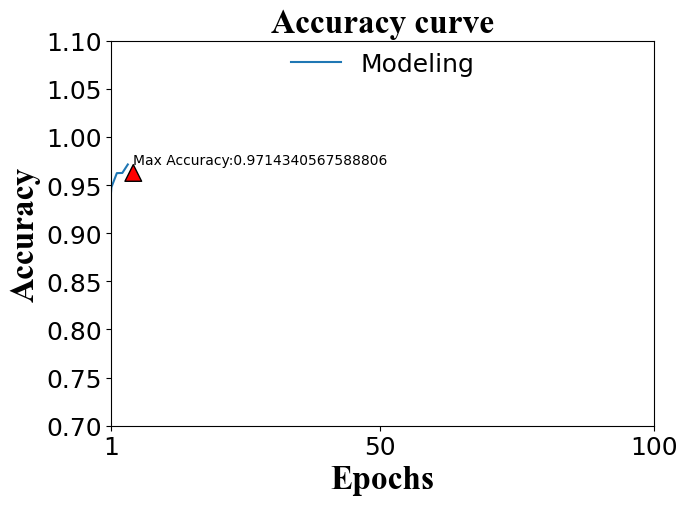

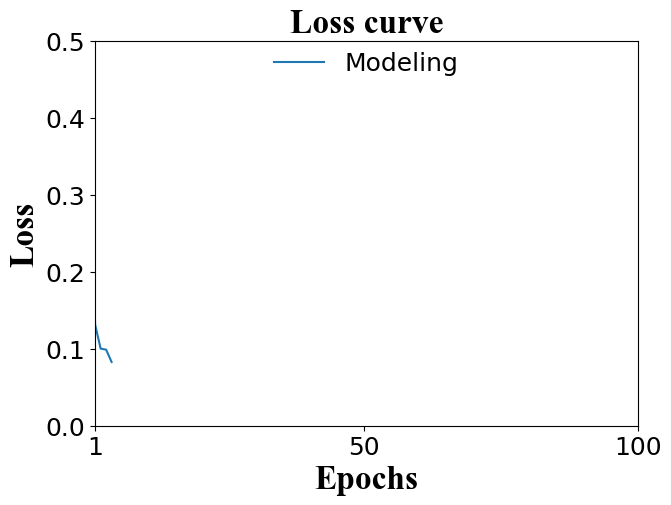

In [8]:
# Plot validation accuracy and loss
history.history['loss']
fig=plt.rc('figure', figsize=(7, 5))

fontLabels = {'family': 'Times New Roman',
        'color':  'black',
        'weight': 'bold',
        'size': 24,
        }

max_=max(history.history['accuracy'])
axisLabelFont=18
#Validation Accuracy Plot   
plt.xticks([1,50,100], fontsize=axisLabelFont)
plt.yticks(fontsize=axisLabelFont)
plt.ylim(ymin=0.7,ymax=1.1) 
plt.xlim(xmin=1, xmax=100)
plt.plot(history.history['accuracy'])
plt.title('Accuracy curve', fontdict=fontLabels)
plt.ylabel('Accuracy', fontdict=fontLabels)
plt.xlabel('Epochs', fontdict=fontLabels)
plt.legend(['Modeling'], loc='upper center', frameon=False, bbox_to_anchor=(0.50, 1.03), shadow=False, ncol=2, fontsize=axisLabelFont)
plt.annotate(f'Max Accuracy:{max_}',xy=(epoch,max_), arrowprops=dict(facecolor='red', shrink=0.05))
# print(max(history.history['accuracy']))
plt.show()
#Validation Loss Plot   
plt.xticks([1,50,100],fontsize=axisLabelFont)
plt.yticks(fontsize=axisLabelFont)
plt.ylim(ymin=0,ymax=0.5) 
plt.xlim(xmin=1, xmax=100)
plt.plot(history.history['loss'])
plt.title('Loss curve', fontdict=fontLabels)
plt.ylabel('Loss', fontdict=fontLabels)
plt.xlabel('Epochs', fontdict=fontLabels)
plt.legend(['Modeling'], loc='upper center', frameon=False, bbox_to_anchor=(0.50, 1.03), shadow=False, ncol=2, fontsize=axisLabelFont)
# print(max("accuracy"))

plt.show()

In [9]:
# Testing/Prediction phase
predictions = model.predict(test_generator, verbose=1)
yPredictions = np.argmax(predictions, axis=1)
true_classes = test_generator.classes
# Display the performance of the model on test data
showResults(true_classes[:len(yPredictions)], yPredictions)

39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 261ms/step
Accuracy  : 0.7708333333333334
Precision : 0.816521685629366
f1Score : 0.7420338068692681
[[ 96 138]
 [  5 385]]


In [10]:
max(history.history['accuracy'])

0.9714340567588806

In [11]:
test_generator.color_mode

'grayscale'

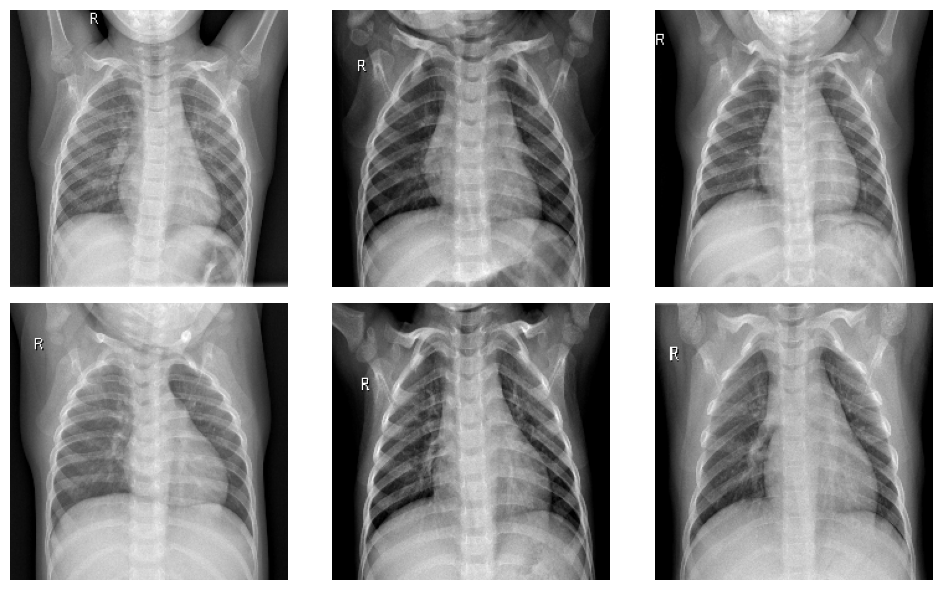

In [16]:
test_pathn ='DS2/DS2/train/NORMAL/'

# create a figure with 2 rows and 3 columns of subplots
fig, axes = plt.subplots(2, 3, figsize=(10, 6))
files = os.listdir(test_pathn)
num_images = min(6, len(files))

for i, filename in enumerate(files[:num_images]):
    # load the image
    img = image.load_img(os.path.join(test_pathn, filename), target_size=(224, 224))
    # get the row and column index of the subplot
    row = i // 3
    col = i % 3
    # display the image in the subplot
    axes[row][col].imshow(img)
    axes[row][col].axis('off')

plt.tight_layout()
plt.show()


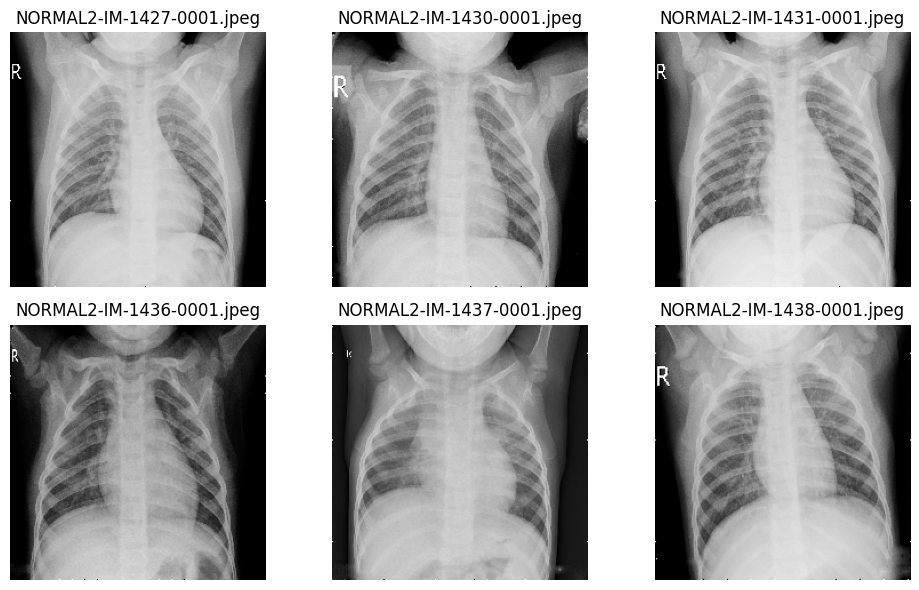

In [18]:
validation_pathn = 'DS2/DS2/validation/NORMAL/'

fig, axes = plt.subplots(2, 3, figsize=(10, 6))
files = os.listdir(validation_pathn)
num_images = min(6, len(files))

for i, filename in enumerate(files[:num_images]):
    img = image.load_img(os.path.join(validation_pathn, filename), target_size=(224, 224))
    row = i // 3
    col = i % 3
    axes[row][col].imshow(img, cmap='gray')
    axes[row][col].set_title(filename)
    axes[row][col].axis('off')

plt.tight_layout()
plt.show()